# HyperRAG V2 — Notebook 2: Simple RAG (Baseline)

**Goal:** Build a minimal but complete RAG pipeline step by step, test every function, and evaluate it on 20 HotpotQA questions.

**Simple RAG in 4 steps:**
1. Embed every page in the corpus as a vector
2. Build a FAISS similarity index
3. For a query, retrieve the top-k most similar pages
4. Return their plain text as context and measure EM / F1

**Prerequisite:** Run `01_data_exploration.ipynb` first to create `data/corpus.json` and `data/questions.json`.


In [4]:
import json
import sys
from pathlib import Path
from collections import Counter

import faiss
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sentence_transformers import SentenceTransformer

# ── Paths ─────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('Run from v2/ or from HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data'
CORPUS_PATH    = DATA_DIR / 'corpus_001.json'
QUESTIONS_PATH = DATA_DIR / 'questions_001.json'

# Load data
with open(CORPUS_PATH)    as f: corpus    = json.load(f)
with open(QUESTIONS_PATH) as f: questions = json.load(f)

print(f'Corpus    : {len(corpus)} pages')
print(f'Questions : {len(questions)} questions')
print(f'Keys: corpus={list(corpus[0].keys())}')


Corpus    : 9999 pages
Questions : 5329 questions
Keys: corpus=['title', 'text', 'html', 'links']


---
## Step 1 — Embed Texts

We convert each Wikipedia page into a **dense vector** using `sentence-transformers/all-MiniLM-L6-v2`.  
Every vector is then **L2-normalised** so that the inner product equals the cosine similarity.

> Cosine similarity = 1.0 means identical direction, 0.0 means completely unrelated.


In [5]:
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
_model = None   # module-level cache so we only load once

def get_model() -> SentenceTransformer:
    """Load (or return cached) SentenceTransformer model."""
    global _model
    if _model is None:
        print(f'Loading model: {MODEL_NAME} ...')
        _model = SentenceTransformer(MODEL_NAME)
        print('Model loaded.')
    return _model


def embed_texts(texts: list[str]) -> np.ndarray:
    """
    Embed a list of strings into L2-normalised float32 vectors.
    Output shape: (len(texts), 384).
    """
    model  = get_model()
    vecs   = model.encode(texts, show_progress_bar=len(texts) > 20, convert_to_numpy=True)
    vecs   = vecs.astype('float32')
    faiss.normalize_L2(vecs)   # in-place L2 normalisation
    return vecs


print('embed_texts() defined.')


embed_texts() defined.


In [6]:
# ── Test embed_texts ──────────────────────────────────────────────────────────
test_texts = [
    'Paris is the capital of France.',
    'Berlin is the capital of Germany.',
    'Mount Everest is the tallest mountain on Earth.',
]
vecs = embed_texts(test_texts)
print(f'Output shape  : {vecs.shape}    (3 texts, 384-dim vectors)')
print(f'Vector dtype  : {vecs.dtype}')
print(f'L2 norms      : {np.linalg.norm(vecs, axis=1)}  (should all be ~1.0)')
print()
# Compute cosine similarities (= dot products after L2 norm)
sim_matrix = vecs @ vecs.T
print('Cosine similarity matrix (Paris, Berlin, Everest):')
print(np.round(sim_matrix, 3))
print('  → Paris↔Berlin should be more similar than Paris↔Everest')


Loading model: sentence-transformers/all-MiniLM-L6-v2 ...
Model loaded.
Output shape  : (3, 384)    (3 texts, 384-dim vectors)
Vector dtype  : float32
L2 norms      : [1. 1. 1.]  (should all be ~1.0)

Cosine similarity matrix (Paris, Berlin, Everest):
[[1.    0.348 0.077]
 [0.348 1.    0.094]
 [0.077 0.094 1.   ]]
  → Paris↔Berlin should be more similar than Paris↔Everest


---
## Step 2 — Build FAISS Index

**FAISS** (Facebook AI Similarity Search) stores all corpus vectors and lets us find the most similar ones to a query vector in milliseconds.

We use `IndexFlatIP` (inner product = cosine similarity after L2 normalisation).


In [7]:
def build_index(corpus: list[dict]) -> faiss.IndexFlatIP:
    """
    Embed every page in corpus and store vectors in a FAISS index.
    The order of pages in the index matches the order in corpus.
    Returns: faiss.IndexFlatIP ready for .search().
    """
    print(f'Embedding {len(corpus)} pages ...')
    texts      = [p['text'] for p in corpus]
    embeddings = embed_texts(texts)
    dim        = embeddings.shape[1]
    index      = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    print(f'Index built: {index.ntotal} vectors, dim={dim}')
    return index


print('build_index() defined.')


build_index() defined.


In [8]:
# ── Test: build index from 3 dummy pages ──────────────────────────────────────
dummy_corpus = [
    {'title': 'Paris',   'text': 'Paris is the capital of France.', 'html': '', 'links': []},
    {'title': 'Berlin',  'text': 'Berlin is the capital of Germany.', 'html': '', 'links': []},
    {'title': 'Everest', 'text': 'Mount Everest is the tallest mountain.', 'html': '', 'links': []},
]
dummy_index = build_index(dummy_corpus)
print(f'Vectors in index : {dummy_index.ntotal}')


Embedding 3 pages ...
Index built: 3 vectors, dim=384
Vectors in index : 3


In [9]:
# Build the real index from our 20-question corpus
index = build_index(corpus)
print(f'Real index ready: {index.ntotal} pages indexed')


Embedding 9999 pages ...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Index built: 9999 vectors, dim=384
Real index ready: 9999 pages indexed


---
## Step 3 — Retrieval Function

For a query string we:
1. Embed the query into a vector
2. Ask FAISS for the k nearest vectors (highest cosine similarity)
3. Map indices back to corpus pages


In [10]:
def retrieve(
    query:  str,
    index:  faiss.IndexFlatIP,
    corpus: list[dict],
    k:      int = 5,
) -> list[dict]:
    """
    Retrieve top-k most similar pages to query.
    Each returned dict has all original keys PLUS '_score' (cosine similarity).
    """
    q_vec = embed_texts([query])
    scores, indices = index.search(q_vec, k)
    results = []
    for idx, score in zip(indices[0], scores[0]):
        if 0 <= idx < len(corpus):
            page = dict(corpus[idx])           # shallow copy
            page['_score'] = float(score)
            results.append(page)
    return results


print('retrieve() defined.')


retrieve() defined.


In [11]:
# ── Test: retrieve top-3 pages for a sample question ─────────────────────────
test_q = questions[0]
print(f'Question : {test_q["question"]}')
print(f'Answer   : {test_q["answer"]}')
print(f'Needs    : {test_q["supporting_titles"]}')
print()

results = retrieve(test_q['question'], index, corpus, k=3)
print('Top-3 retrieved pages:')
print(f'{"Rank":<5} {"Score":>6}  {"Title"}')
print('-' * 55)
for rank, page in enumerate(results, 1):
    is_gold = '✓' if page['title'] in test_q['supporting_titles'] else ' '
    print(f'{rank:<5} {page["_score"]:>6.3f}  {is_gold} {page["title"]}')


Question : The Oberoi family is part of a hotel company that has a head office in what city?
Answer   : Delhi
Needs    : ['The Oberoi Group', 'Oberoi family']

Top-3 retrieved pages:
Rank   Score  Title
-------------------------------------------------------
1      0.651  ✓ Oberoi family
2      0.651  ✓ The Oberoi Group
3      0.396    Allard Roen


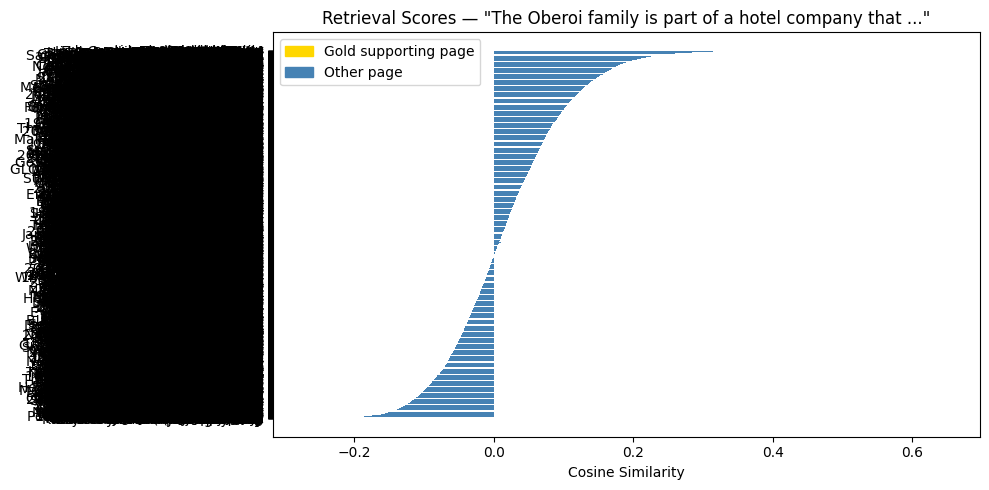

In [12]:
# Visualize similarity scores for the first question
results_5 = retrieve(test_q['question'], index, corpus, k=len(corpus))
titles = [p['title'][:30] for p in results_5]
scores = [p['_score'] for p in results_5]
gold   = set(test_q['supporting_titles'])
colors = ['gold' if t in gold else 'steelblue' for t in [p['title'] for p in results_5]]

plt.figure(figsize=(10, 5))
plt.barh(titles[::-1], scores[::-1], color=colors[::-1])
plt.xlabel('Cosine Similarity')
plt.title(f'Retrieval Scores — "{test_q["question"][:50]}..."')
gold_patch  = mpatches.Patch(color='gold',      label='Gold supporting page')
blue_patch  = mpatches.Patch(color='steelblue', label='Other page')
plt.legend(handles=[gold_patch, blue_patch])
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'simple_rag_scores.png'), dpi=100, bbox_inches='tight')
plt.show()


---
## Step 4 — Evaluation Metrics: EM and F1

We measure retrieval quality — not generation quality:
- **EM (Exact Match):** 1 if the gold answer string appears in the retrieved context
- **F1:** token-level word overlap between context and gold answer
- **Supporting Recall:** fraction of gold pages that were retrieved (best metric for multi-hop)


In [13]:
def compute_em(context: str, gold_answer: str) -> float:
    """
    Exact Match: 1.0 if gold answer appears case-insensitively in context.
    Simple substring check — fast and interpretable.
    """
    return 1.0 if gold_answer.lower() in context.lower() else 0.0


def compute_f1(context: str, gold_answer: str) -> float:
    """
    Token F1: word-level overlap between context and gold answer.
    Based on multiset intersection of lowercased whitespace tokens.
    """
    pred_tokens = context.lower().split()
    gold_tokens = gold_answer.lower().split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    pred_c  = Counter(pred_tokens)
    gold_c  = Counter(gold_tokens)
    overlap = sum((pred_c & gold_c).values())
    precision = overlap / len(pred_tokens)
    recall    = overlap / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def compute_supporting_recall(
    retrieved_titles: list[str],
    gold_titles:      list[str],
) -> float:
    """
    What fraction of the gold supporting pages were retrieved?
    This is the KEY metric for multi-hop retrieval.
    Example: gold=[A,B], retrieved=[A,C,D] → recall = 0.5
    """
    if not gold_titles:
        return 0.0
    hits = sum(1 for t in gold_titles if t in set(retrieved_titles))
    return hits / len(gold_titles)


print('compute_em(), compute_f1(), compute_supporting_recall() defined.')


compute_em(), compute_f1(), compute_supporting_recall() defined.


In [14]:
# ── Test each metric on a hand-crafted example ───────────────────────────────
context      = 'The capital of France is Paris and it is a famous city.'
gold_answer  = 'Paris'

em = compute_em(context, gold_answer)
f1 = compute_f1(context, gold_answer)
print(f'context : "{context}"')
print(f'gold    : "{gold_answer}"')
print(f'EM      : {em}   (1.0 because "Paris" is in the context)')
print(f'F1      : {f1:.3f}')
print()

context2     = 'Berlin is a big city in Germany.'
gold_answer2 = 'Paris'
em2 = compute_em(context2, gold_answer2)
f1_2 = compute_f1(context2, gold_answer2)
print(f'context : "{context2}"')
print(f'gold    : "{gold_answer2}"')
print(f'EM      : {em2}   (0.0 because "Paris" is NOT in the context)')
print(f'F1      : {f1_2:.3f}')
print()

# Supporting recall
recall_full  = compute_supporting_recall(['A', 'B', 'C'], ['A', 'B'])
recall_half  = compute_supporting_recall(['A', 'C', 'D'], ['A', 'B'])
recall_zero  = compute_supporting_recall(['C', 'D', 'E'], ['A', 'B'])
print(f'Supporting recall (got both gold pages)   : {recall_full}')
print(f'Supporting recall (got one of two)        : {recall_half}')
print(f'Supporting recall (got neither gold page) : {recall_zero}')


context : "The capital of France is Paris and it is a famous city."
gold    : "Paris"
EM      : 1.0   (1.0 because "Paris" is in the context)
F1      : 0.154

context : "Berlin is a big city in Germany."
gold    : "Paris"
EM      : 0.0   (0.0 because "Paris" is NOT in the context)
F1      : 0.000

Supporting recall (got both gold pages)   : 1.0
Supporting recall (got one of two)        : 0.5
Supporting recall (got neither gold page) : 0.0


---
## Step 5 — Full Simple RAG Pipeline

Put everything together: retrieve top-k pages and concatenate their plain text as context.


In [15]:
def simple_rag(
    question: str,
    index:    faiss.IndexFlatIP,
    corpus:   list[dict],
    k:        int = 5,
) -> str:
    """
    Simple RAG: retrieve top-k pages, return plain text concatenated.
    This is the baseline (B1) all other systems are compared against.
    """
    pages   = retrieve(question, index, corpus, k=k)
    context = '\n\n'.join(p['text'] for p in pages)
    return context


print('simple_rag() defined.')


simple_rag() defined.


In [16]:
# ── Test the full pipeline on question 0 ─────────────────────────────────────
q    = questions[0]
ctx  = simple_rag(q['question'], index, corpus, k=5)
em   = compute_em(ctx, q['answer'])
f1   = compute_f1(ctx, q['answer'])

print(f'Question         : {q["question"]}')
print(f'Gold answer      : {q["answer"]}')
print(f'Supporting pages : {q["supporting_titles"]}')
print(f'Context length   : {len(ctx)} chars')
print(f'EM               : {em}')
print(f'F1               : {f1:.3f}')
print()
print('Context preview (first 400 chars):')
print(ctx[:400])


Question         : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer      : Delhi
Supporting pages : ['The Oberoi Group', 'Oberoi family']
Context length   : 40347 chars
EM               : 1.0
F1               : 0.000

Context preview (first 400 chars):
Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in New Delhi , India . Founded in 1934, the company owns and operates 32 luxury hotels and two river cruise ships in 7 countries, primarily under its Oberoi Hotels & Resorts and Trident brands. The group also operates The Oberoi Centre of Learning and Development, which is regarded as one of Asia 's top institu


---
## Step 6 — Evaluate on All 20 Questions


In [17]:
K = 5   # number of pages to retrieve

results_simple = []
for q in questions:
    pages   = retrieve(q['question'], index, corpus, k=K)
    context = '\n\n'.join(p['text'] for p in pages)
    ret_titles = [p['title'] for p in pages]

    em       = compute_em(context, q['answer'])
    f1       = compute_f1(context, q['answer'])
    sp_recall = compute_supporting_recall(ret_titles, q['supporting_titles'])

    results_simple.append({
        'id':               q['id'],
        'question':         q['question'],
        'answer':           q['answer'],
        'em':               em,
        'f1':               f1,
        'supporting_recall': sp_recall,
        'retrieved_titles': ret_titles,
    })

mean_em  = sum(r['em']  for r in results_simple) / len(results_simple)
mean_f1  = sum(r['f1']  for r in results_simple) / len(results_simple)
mean_spr = sum(r['supporting_recall'] for r in results_simple) / len(results_simple)

print('Simple RAG Results (k=5)')
print('=' * 50)
print(f'Mean EM               : {mean_em:.3f}')
print(f'Mean F1               : {mean_f1:.3f}')
print(f'Mean Supporting Recall: {mean_spr:.3f}')


Simple RAG Results (k=5)
Mean EM               : 0.682
Mean F1               : 0.000
Mean Supporting Recall: 0.663


In [18]:
# Per-question results table
print(f'{"#":<4} {"EM":>4} {"F1":>6} {"SR":>6}  Answer')
print('-' * 60)
for r in results_simple:
    print(f'{r["id"]:<4} {r["em"]:>4.0f} {r["f1"]:>6.3f} {r["supporting_recall"]:>6.3f}  {r["answer"][:30]}')


#      EM     F1     SR  Answer
------------------------------------------------------------
0       1  0.000  1.000  Delhi
1       1  0.001  1.000  President Richard Nixon
2       1  0.000  0.500  American
3       1  0.000  0.500  alcohol
4       1  0.003  0.500  Crambidae
5       1  0.000  0.500  Badr Hari
6       1  0.000  1.000  2006
7       0  0.001  1.000  6.213 km long
8       0  0.000  0.500  Jaime Meline
9       0  0.000  0.500  Walter Darwin Coy
10      1  0.000  1.000  United States
11      1  0.000  0.500  Super Bowl XLVIII
12      1  0.000  0.500  US 60
13      1  0.000  0.500  2006
14      0  0.001  1.000  Hetfield and Ulrich, longtime 
15      1  0.000  0.500  Fox
16      1  0.000  1.000  2017
17      1  0.000  1.000  Nevada
18      1  0.000  0.500  Hawaii
19      1  0.000  0.500  Kelli Ward
20      0  0.000  0.500  16-year-old
21      0  0.000  0.500  World War II
22      0  0.000  0.000  Todd Phillips
23      1  0.000  0.500  Carol Lawrence
24      1  0.001  0.500  Amy

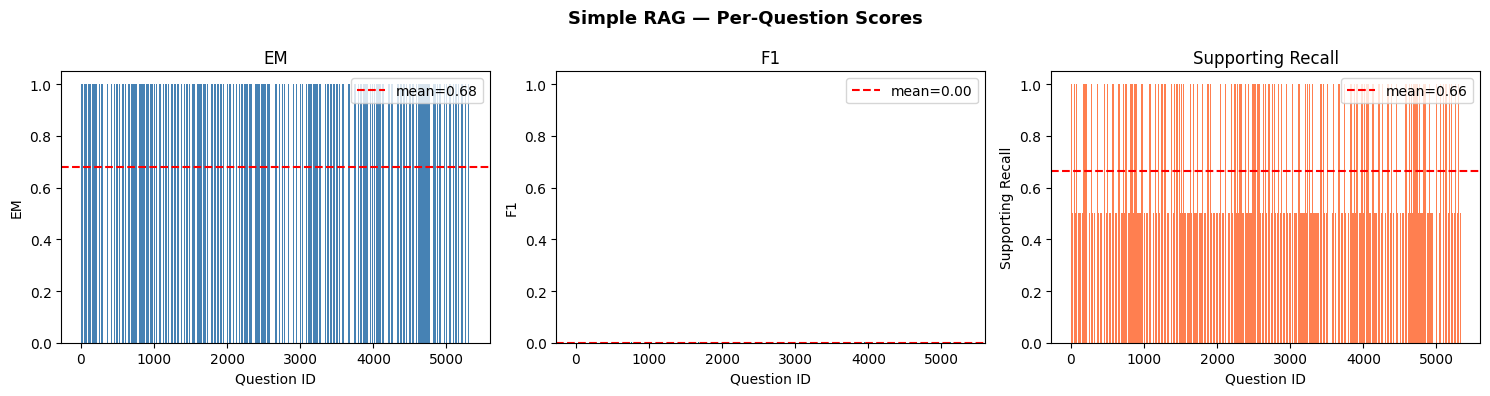

Saved: data/simple_rag_results.png


In [19]:
em_vals  = [r['em']  for r in results_simple]
f1_vals  = [r['f1']  for r in results_simple]
sr_vals  = [r['supporting_recall'] for r in results_simple]
ids      = [r['id']  for r in results_simple]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Simple RAG — Per-Question Scores', fontsize=13, fontweight='bold')

for ax, vals, label, color, mean_val in [
    (axes[0], em_vals,  'EM',               'steelblue', mean_em),
    (axes[1], f1_vals,  'F1',               'teal',      mean_f1),
    (axes[2], sr_vals,  'Supporting Recall', 'coral',    mean_spr),
]:
    ax.bar(ids, vals, color=color)
    ax.axhline(mean_val, color='red', linestyle='--', label=f'mean={mean_val:.2f}')
    ax.set_xlabel('Question ID')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'simple_rag_results.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/simple_rag_results.png')


In [20]:
# Save results for comparison in notebook 4
import json
with open(DATA_DIR / 'results_simple_rag.json', 'w') as f:
    json.dump({'mean_em': mean_em, 'mean_f1': mean_f1, 'mean_sr': mean_spr,
               'per_question': results_simple}, f, indent=2)
print('Results saved → data/results_simple_rag.json')
print()
print('Open notebook 03_htmlrag.ipynb next.')


Results saved → data/results_simple_rag.json

Open notebook 03_htmlrag.ipynb next.
